# Preparation for interpolation

Confidence interval version

In [1]:
import sys
sys.path.append('../../Python_scripts')

## Import packages
from config import *
from support import *
from cosmo_support import *

path='./interpolation/095_C0mean.npz'

/home/zhuge/miniconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


# Preparation interpolation

search F range 

In [2]:
sigma = 3.0
C0 = find_C0_sigma(sigma,
                 condition='mean'
                  )
A = find_A_sigma(C_0=C0, sigma=sigma)
def cdf(Delta):
            integral, _ = quad(lambda x: pdf_DM_cosmo(x, C_0=C0, A=A, sigma=sigma, alpha=3, beta=3), 1e-10, Delta)
            return integral
int95=calc_confidence_interval_width(cdf=cdf, 
                                              target_prob= 0.9545 # 0.6827 #0.9545 # 0.6827
                                              )
int68=calc_confidence_interval_width(cdf=cdf, 
                                              target_prob= 0.6827 #0.9545 # 0.6827
                                              )
int99=calc_confidence_interval_width(cdf=cdf, 
                                              target_prob= 0.9973 #0.9545 # 0.6827
                                              )

print(C0, A, int99/3, int95/2, int68)

-4.591250937581971 0.6117505483935499 4.584575887089302 1.5165856535157842 0.7974659769373595


In [3]:
sigma_rsl = 2000
Sigmas = np.linspace(0.01, 8.0, sigma_rsl)
# Sigmas = np.linspace(0.01, 8, sigma_rsl)
print([np.min(Sigmas), np.max(Sigmas)])

C0s = np.zeros_like(Sigmas)
As = np.zeros_like(Sigmas)
Errors = np.zeros_like(Sigmas)

pbar = tqdm(Sigmas)
for i, sigma in enumerate(pbar):
    pbar.set_description(f"Processing sigma={sigma:.4f}")
    
    C0 = find_C0_sigma(sigma,
                 condition='mean'
                  )
    C0s[i] = C0
    
    if C0==None:
        print(f"Warning: C0 is None for sigma={sigma:.4f}")
        A=None
        Errors[i] = None
    else:
        A = find_A_sigma(C_0=C0, sigma=sigma)
        As[i] = A
        
        def cdf(Delta):
            integral, _ = quad(lambda x: pdf_DM_cosmo(x, C_0=C0, A=A, sigma=sigma, alpha=3, beta=3), 1e-10, Delta)
            return integral
        
        sigma2=calc_confidence_interval_width(cdf=cdf, 
                                              target_prob= 0.9545
                                              )
        
        # old function
        """ sigma2=calc_confidence_interval_width(sigma=sigma, C_0=C0, A=A, 
                                              target_prob= 0.6827 #0.9545 # 0.6827
                                              ) """
        Errors[i] = sigma2/4  # Divide to get the width of the confidence interval 2*(0.6827: 1 sigma, 0.9545: 2 sigma, 0.9973: 3 sigma)

[0.01, 8.0]


Processing sigma=8.0000: 100%|██████████| 2000/2000 [16:22<00:00,  2.04it/s] 


In [4]:
mask = ~pd.isnull(C0s) & ~pd.isnull(As) & ~pd.isnull(Errors)
C0s = C0s[mask]
As = As[mask]
Errors = Errors[mask]
Sigmas = Sigmas[mask]
print(len(Sigmas), len(C0s), len(As), len(Errors))

2000 2000 2000 2000


In [5]:
# sigma_rsl=5000
# # Sigmas=np.linspace(sigma_min, sigma_max, sigma_rsl)
# Sigmas=np.linspace(0.1, 59.0, sigma_rsl)
# print([np.min(Sigmas),np.max(Sigmas)])
# C0s=np.zeros_like(Sigmas)
# As=np.zeros_like(Sigmas)
# Error_sqrt=np.zeros_like(Sigmas)
# for i, sigma in enumerate(Sigmas):
#     C0=C0_sigma(sigma)
#     C0s[i]=C0
#     A=find_A_sigma(C_0=C0, sigma=sigma)
#     As[i]=A
#     Error_sqrt[i]=np.sqrt(calculate_var(C0=C0, A=A, sigma_DM=sigma))

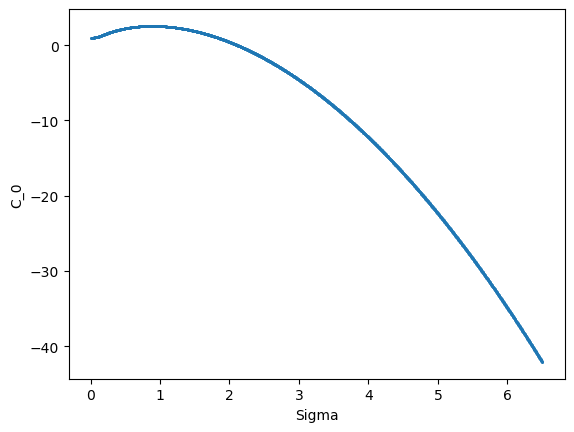

In [6]:
plt.scatter(Sigmas, C0s,  s=1)

plt.ylabel('C_0')
plt.xlabel('Sigma')
# plt.xlim(0,10)

plt.show()

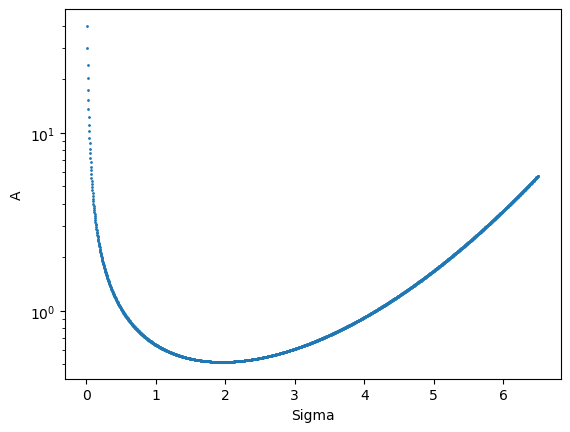

In [7]:
plt.scatter(Sigmas, As,  s=1)

plt.ylabel('A')
plt.xlabel('Sigma')
plt.yscale('log')
# plt.xlim(0,10)

plt.show()

Text(0.5, 0, 'Error')

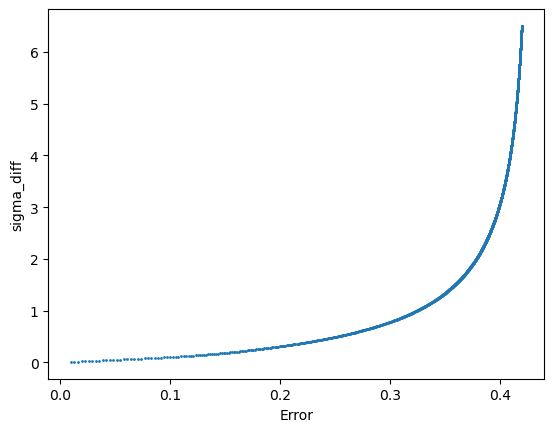

In [8]:
plt.scatter(Errors, Sigmas,s=1)
plt.ylabel('sigma_diff')
plt.xlabel('Error')
# plt.xlim(0.7, 0.8)
# plt.xscale('log')
# plt.yscale('log')

Text(0.5, 0, 'Sigma')

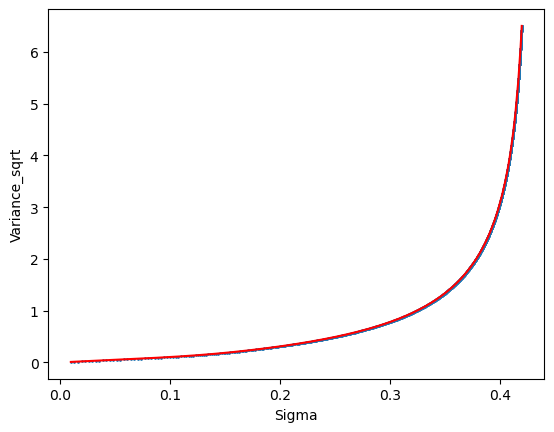

In [9]:
inter_sigma=interpolate.interp1d(Sigmas, Errors, kind=1,bounds_error=False, 
    # fill_value='extrapolate'
    )
re_sigmas=np.linspace(np.min(Sigmas), np.max(Sigmas), 2*sigma_rsl)
re_var_sqrt=inter_sigma(re_sigmas)
plt.plot(re_var_sqrt, re_sigmas, 'r-', label='interpolated')
plt.scatter(Errors, Sigmas, s=1, label='original')
plt.ylabel('Variance_sqrt')
plt.xlabel('Sigma')

In [10]:
np.savez(path, a=Sigmas, b=As, c=C0s, d=Errors)

load data, fitting for F
move to `updown_cal.ipynb`

In [2]:
load_arrays=np.load(path)
Sigmas=load_arrays['a']
Errors=load_arrays['d']
C0s=load_arrays['c']
As=load_arrays['b']

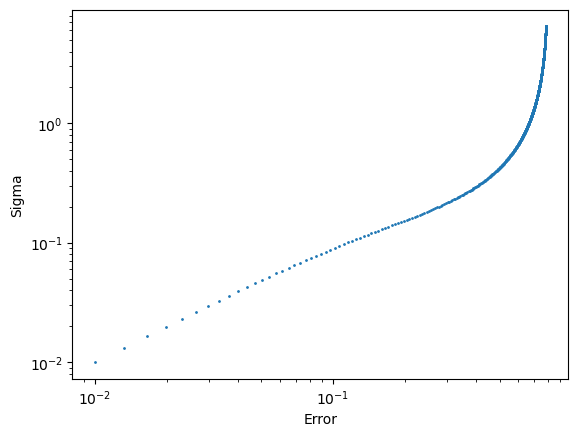

In [3]:
plt.scatter(Errors, Sigmas, s=1)
plt.ylabel('Sigma')
plt.xlabel('Error')
plt.xscale('log')
plt.yscale('log')

0.06885182186659902
0.06519259629814908


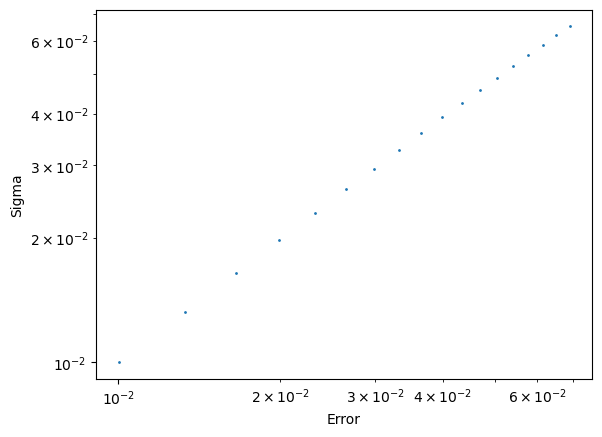

In [4]:
th=0.07
fit_error=Errors[Errors<=th]
fit_Sigmas=Sigmas[Errors<=th]
print(max(fit_error))
print(max(fit_Sigmas))
plt.scatter(fit_error, fit_Sigmas, s=1)
plt.ylabel('Sigma')
plt.xlabel('Error')
plt.xscale('log')
plt.yscale('log')

In [5]:
sigma=0.34
F=0.31
z=F/sigma
z=z**2
print(z)

0.8313148788927335


In [6]:
log_errors=np.log10(fit_error)
log_Sigmas=np.log10(fit_Sigmas)

def fit_fun(x, b):
    return x+b

popt, pcov = curve_fit(fit_fun, log_errors, log_Sigmas)
print(popt)
b=popt[0]
k=10**b
print(k)

[-0.00928051]
0.9788575323554154


In [ ]:
standard=np.sqrt(0.025)*k
print(np.sqrt(0.025+0.006)*k-standard)
print(standard)
# print(standard-np.sqrt(0.025-0.008)*c)

0.017574687705618736
0.15477096535275384


NameError: name 'c' is not defined

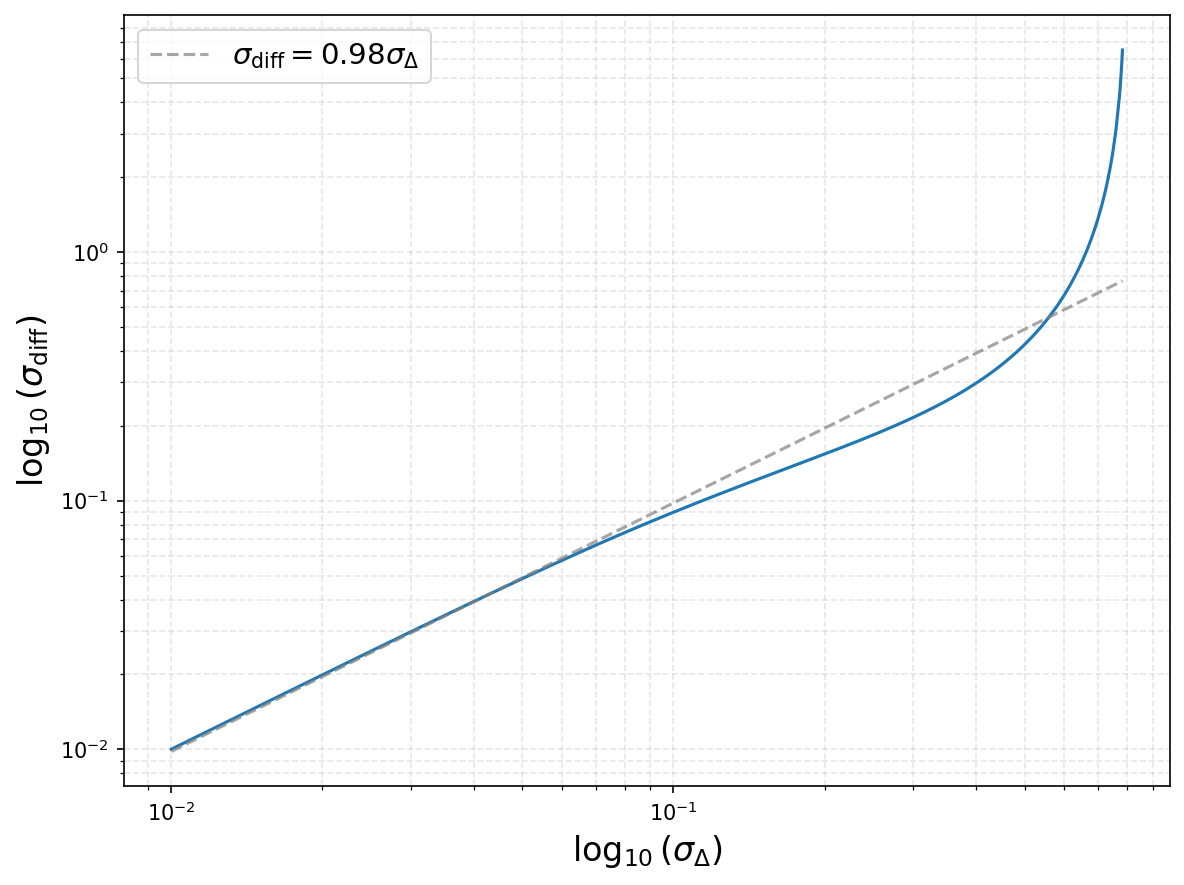

In [10]:
plt.figure(figsize=(8, 6),dpi=150)
fs=16
# plt.scatter(Errors, Sigmas,s=0.5)
plt.plot(Errors, Sigmas)
plt.ylabel(r'$\log_{10} (\sigma_{\rm diff})$',fontsize=fs)
plt.xlabel(r'$\log_{10} (\sigma_\Delta)$',fontsize=fs)
plt.xscale('log',base=10)
plt.yscale('log',base=10)

x_min = min(Errors)
x_max = max(Errors)
x_range = np.logspace(np.log10(x_min), np.log10(x_max), 100)

y_ref = x_range * k
plt.plot(x_range, y_ref, '--', color='gray', alpha=0.7, 
             label=r'$\sigma_{\rm diff} ='+f' {k:.2f}'+r'\sigma_\Delta $')

""" constants = [b-1, b-0.5, b, b+0.5, b+1]
for c in constants:
    const=(10**c)
    y_ref = x_range * const  # y = x * 10^c
    plt.plot(x_range, y_ref, '--', color='gray', alpha=0.7, 
             label=r'$\sigma_{\rm diff} ='+f' ({const:.2e})'+r'\sigma_\Delta $') """

plt.grid(True, which="both", ls="--", alpha=0.3)
plt.legend(fontsize=fs-2)
plt.tight_layout()
plt.savefig('./plot/sigma_diff_vs_sigma_delta.pdf', dpi=150)

In [18]:
# interpolation example

# C0_sigma = interpolate.interp1d(Sigmas, C0s, kind=1,bounds_error=False, 
#     # fill_value='extrapolate'
#     )

# A_sigma = interpolate.interp1d(Sigmas, As, kind=1,bounds_error=False, 
#     # fill_value='extrapolate'
#     )

# sigma_var = interpolate.interp1d(Error, Sigmas, kind=1,bounds_error=False, 
#     # fill_value='extrapolate'
#     )

In [19]:
# np.save('./interpolation/Sigmas.npy', Sigmas)
# np.save('./interpolation/As.npy', As)
# np.save('./interpolation/C0s.npy', C0s)
# np.save('./interpolation/Errors.npy', Errors)